This notebook aims to replicate the Real Business Cycle (RBC) model solution from (Guerrieri, Iacoviello, 2015). Instead of a polynomial approximation, this code implements artificial neural networks as policy functions.

The code is based on the following works:

https://github.com/JohannesPfeifer/DSGE_mod/blob/master/Guerrieri_Iacoviello_2015/Guerrieri_Iacoviello_2015_rbc.mod

https://www.matteoiacoviello.com/research_files/JME_2015.pdf

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers
from scipy.optimize import minimize
from scipy.optimize import fsolve
from scipy.optimize import root
from scipy.optimize import least_squares
from scipy.optimize import newton_krylov
from scipy.optimize import anderson

from datetime import datetime
import math

## Calibration and steady state

In [ ]:
alpha=0.33;
beta=0.96;
depr=0.1;

kss = (alpha/(1/beta - 1 + depr))**(1/(1-alpha))
iss = depr*kss
yss = (alpha/(1/beta - 1 + depr))**(alpha/(1-alpha))
css = yss-iss
rss = 1/beta
wss = (1-alpha)*yss
zss = 1

rho=0.9;
sigma=2.0;
phi=0.975;
stde=0.013;

## Linearized solution

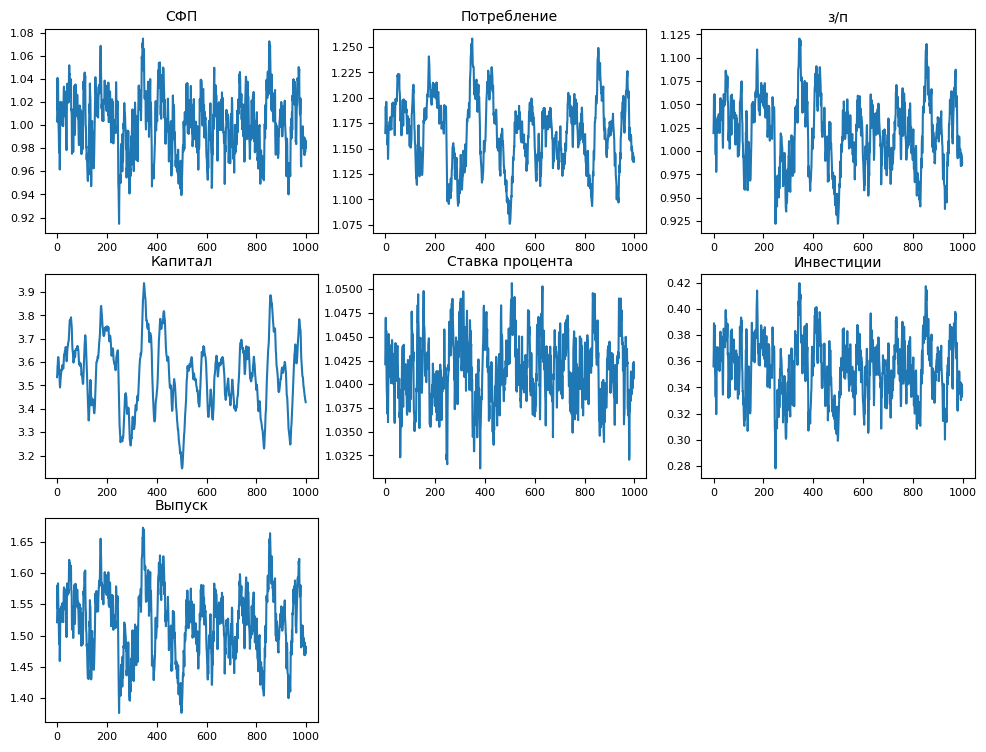

In [ ]:
T=1000;
n_series = 1

for j in range(n_series):

  e_list = np.reshape(np.random.normal(loc=0.0, scale=stde, size=T), (T, 1))
  k_list = np.zeros((T,1))
  z_list = np.zeros((T,1))
  y_list = np.zeros((T,1))
  c_list = np.zeros((T,1))
  i_list = np.zeros((T,1))
  l_list = np.zeros((T,1))
  w_list = np.zeros((T,1))
  r_list = np.zeros((T,1))
  k_list[0] = kss;
  z_list[0] = zss;

  for t in range(1,T):
    k_list[t] = 3.532879   + 0.902615*(k_list[t-1]-3.53288) + 0.789497*(z_list[t-1]-1.000) + 0.877219*e_list[t]
    z_list[t] = 1          +                                      0.90*(z_list[t-1]-1.000) + 1.000000*e_list[t]
    y_list[t] = 1.516640   + 0.141667*(k_list[t-1]-3.53288) + 1.364976*(z_list[t-1]-1.000) + 1.516640*e_list[t]
    c_list[t] = 1.163352   + 0.139052*(k_list[t-1]-3.53288) + 0.575479*(z_list[t-1]-1.000) + 0.639421*e_list[t]
    i_list[t] = 0.353288   + 0.002615*(k_list[t-1]-3.53288) + 0.789497*(z_list[t-1]-1.000) + 0.877219*e_list[t]
    w_list[t] = 1.016149   + 0.094917*(k_list[t-1]-3.53288) + 0.914534*(z_list[t-1]-1.000) + 1.016149*e_list[t]
    r_list[t] = 1.041667   - 0.026867*(k_list[t-1]-3.53288) + 0.127500*(z_list[t-1]-1.000) + 0.141667*e_list[t]


fig, axs = plt.subplots(3,3, figsize=(12,9))
axs[0,0].plot(z_list[1:T])
axs[0,0].set_title('СФП')
axs[0,1].plot(c_list[1:T])
axs[0,1].set_title('Потребление')
axs[1,0].plot(k_list[1:T])
axs[1,0].set_title('Капитал')
axs[1,1].plot(r_list[1:T])
axs[1,1].set_title('Ставка процента')
axs[0,2].plot(w_list[1:T])
axs[0,2].set_title('з/п')
axs[1,2].plot(i_list[1:T])
axs[1,2].set_title('Инвестиции')
axs[2,0].plot(y_list[1:T])
axs[2,0].set_title('Выпуск')

axs[2,1].axis('off')
axs[2,2].axis('off')

plt.show()

## Initial guess for policy function (training on linear model data)

In [ ]:
############### Step 0: f) Choose approximating functions (neural networks) for parameterizingthe intertemporal choice  #################

mlp_model_c = Sequential()
mlp_model_c.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
mlp_model_c.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
mlp_model_c.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))

mlp_model_c.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])

###############

mlp_model_r = Sequential()
mlp_model_r.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
mlp_model_r.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
mlp_model_r.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))

mlp_model_r.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])

###############

mlp_model_y = Sequential()
mlp_model_y.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
mlp_model_y.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
mlp_model_y.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))

mlp_model_y.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])

###############

mlp_model_k = Sequential()
mlp_model_k.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
mlp_model_k.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
mlp_model_k.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))#, kernel_regularizer=regularizers.l2(0.001)))

mlp_model_k.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.02), metrics=['mse'])

###############

mlp_model_z = Sequential()
mlp_model_z.add(Dense(72, kernel_initializer='he_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
mlp_model_z.add(Dense(72, kernel_initializer='he_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
mlp_model_z.add(Dense(1, kernel_initializer='he_uniform', bias_initializer="he_uniform", activation='softplus'))#, kernel_regularizer=regularizers.l2(0.001)))

mlp_model_z.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.02), metrics=['mse'])

###############

mlp_model_i = Sequential()
mlp_model_i.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
mlp_model_i.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
mlp_model_i.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))

mlp_model_i.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), metrics=['mse']) # было 0.01

###############

mlp_model_w = Sequential()
mlp_model_w.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
mlp_model_w.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
mlp_model_w.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))

mlp_model_w.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])

In [ ]:
mlp_model_mu = Sequential()
mlp_model_mu.add(Dense(72, kernel_initializer='zeros', bias_initializer="zeros", activation='swish'))
mlp_model_mu.add(Dense(72, kernel_initializer='zeros', bias_initializer="zeros", activation='swish'))
mlp_model_mu.add(Dense(1, kernel_initializer='zeros', bias_initializer="zeros", activation='swish'))

mlp_model_mu.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])
#mlp_model_mu(X_nn_init)

In [ ]:
############### Step 0: g) Use the perturbation solution Y(·; bY ) to construct an initial guess on weights   #################

time_start = datetime.now()
print('start time: {}'.format(time_start))

k_store_nn = np.reshape(k_list, (len(k_list),-1))
X_nn_init = np.dstack([(k_store_nn[:-1, ]-kss).flatten(), (z_list[:-1, ]-zss).flatten(), e_list[1:, ].flatten()])[0]
X_nn_init = tf.convert_to_tensor(X_nn_init, dtype = tf.float32)

opt_correct_z = tf.reshape(tf.convert_to_tensor(z_list[1:, ], dtype = tf.float32), shape=(len(z_list[1:, ]),1))
opt_correct_k = tf.reshape(tf.convert_to_tensor(k_list[1:, ], dtype = tf.float32), shape=(len(k_list[1:, ]),1))
opt_correct_c = tf.reshape(tf.convert_to_tensor(c_list[1:, ], dtype = tf.float32), shape=(len(c_list[1:, ]),1))
opt_correct_r = tf.reshape(tf.convert_to_tensor(r_list[1:, ], dtype = tf.float32), shape=(len(r_list[1:, ]),1))
opt_correct_y = tf.reshape(tf.convert_to_tensor(y_list[1:, ], dtype = tf.float32), shape=(len(y_list[1:, ]),1))
opt_correct_i = tf.reshape(tf.convert_to_tensor(i_list[1:, ], dtype = tf.float32), shape=(len(i_list[1:, ]),1))
opt_correct_w = tf.reshape(tf.convert_to_tensor(w_list[1:, ], dtype = tf.float32), shape=(len(w_list[1:, ]),1))

mse=tf.keras.losses.MeanSquaredError()

callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5000, baseline = 0, restore_best_weights=True, start_from_epoch=2000)

mlp_model_k.fit(X_nn_init, opt_correct_k, verbose=0, epochs=40000, batch_size=T, callbacks=[callback])
print('model for k finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_k.evaluate(X_nn_init, opt_correct_k, verbose=0)[0], datetime.now()-time_start))
mlp_model_z.fit(X_nn_init, opt_correct_z, verbose=0, epochs=30000, batch_size=T, callbacks=[callback])
print('model for z finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_z.evaluate(X_nn_init, opt_correct_z, verbose=0)[0], datetime.now()-time_start))
mlp_model_c.fit(X_nn_init, opt_correct_c, verbose=0, epochs=12000, batch_size=T, callbacks=[callback])
print('model for c finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_c.evaluate(X_nn_init, opt_correct_c, verbose=0)[0], datetime.now()-time_start))
mlp_model_r.fit(X_nn_init, opt_correct_r, verbose=0, epochs=20000, batch_size=T, callbacks=[callback])
print('model for r finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_r.evaluate(X_nn_init, opt_correct_r, verbose=0)[0], datetime.now()-time_start))
mlp_model_y.fit(X_nn_init, opt_correct_y, verbose=0, epochs=12000, batch_size=T, callbacks=[callback])
print('model for y finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_y.evaluate(X_nn_init, opt_correct_y, verbose=0)[0], datetime.now()-time_start))
mlp_model_i.fit(X_nn_init, opt_correct_i, verbose=0, epochs=40000, batch_size=T, callbacks=[callback])
print('model for i finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_i.evaluate(X_nn_init, opt_correct_i, verbose=0)[0], datetime.now()-time_start))
mlp_model_w.fit(X_nn_init, opt_correct_w, verbose=0, epochs=12000, batch_size=T, callbacks=[callback])
print('model for w finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_w.evaluate(X_nn_init, opt_correct_w, verbose=0)[0], datetime.now()-time_start))

start time: 2023-05-22 20:05:31.831593
model for k finished training. loss: 8.227679648697972e-10, ---- time sinse start: 0:02:24.148157
model for z finished training. loss: 2.3672899196469643e-09, ---- time sinse start: 0:03:47.287311
model for c finished training. loss: 9.47569800402448e-10, ---- time sinse start: 0:04:57.302704
model for r finished training. loss: 1.7791207743145243e-11, ---- time sinse start: 0:06:06.589423
model for y finished training. loss: 8.43550207463295e-09, ---- time sinse start: 0:07:29.707576
model for i finished training. loss: 4.084382609903514e-09, ---- time sinse start: 0:08:52.863813
model for w finished training. loss: 2.903344231697247e-08, ---- time sinse start: 0:10:05.080820


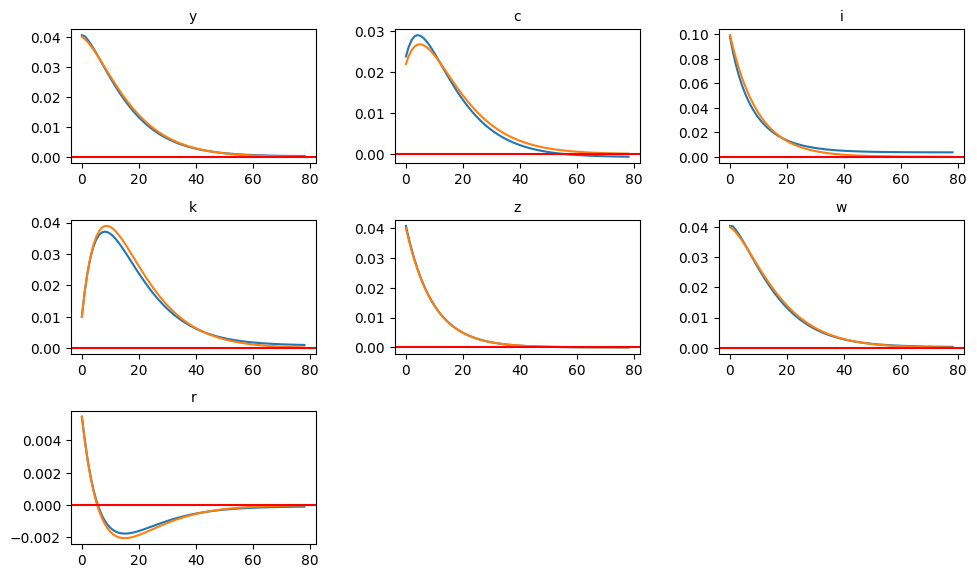

In [ ]:
T_irf=80;
e_list_plot=np.reshape(np.random.uniform(0, 0, size=T_irf), (T_irf, 1))
e_list_plot[1] = 0.04 #stde

z_list_plot=np.zeros((T_irf,1));
z_list_plot[0]=zss;

k_list_plot=np.zeros((T_irf,1));
k_list_plot[0]=kss;

y_list_plot=np.zeros((T_irf,1));
y_list_plot[0]=yss;

c_list_plot=np.zeros((T_irf,1));
c_list_plot[0]=css;

i_list_plot=np.zeros((T_irf,1));
i_list_plot[0]=iss;

w_list_plot=np.zeros((T_irf,1));
w_list_plot[0]=wss;

r_list_plot=np.zeros((T_irf,1));
r_list_plot[0]=rss;

for i in range(1,T_irf):
  # k_list_plot[i] = 3.532879   + 0.902510*(k_list_plot[i-1]-3.53288) + 0.841969*(z_list_plot[i-1]-1.000) + 0.935521*e_list_plot[i]
  # z_list_plot[i] = 1          +                                           0.90*(z_list_plot[i-1]-1.000) + 1.000000*e_list_plot[i]
  # y_list_plot[i] = 1.516640   + 0.127856*(k_list_plot[i-1]-3.53288) + 1.484255*(z_list_plot[i-1]-1.000) + 1.649172*e_list_plot[i]
  # c_list_plot[i] = 1.163352   + 0.125346*(k_list_plot[i-1]-3.53288) + 0.642286*(z_list_plot[i-1]-1.000) + 0.713651*e_list_plot[i]
  # i_list_plot[i] = 0.353288   + 0.002510*(k_list_plot[i-1]-3.53288) + 0.841969*(z_list_plot[i-1]-1.000) + 0.935521*e_list_plot[i]
  # w_list_plot[i] = 1.016149   + 0.085663*(k_list_plot[i-1]-3.53288) + 0.994451*(z_list_plot[i-1]-1.000) + 1.104945*e_list_plot[i]
  # r_list_plot[i] = 1.041667   - 0.024247*(k_list_plot[i-1]-3.53288) + 0.104879*(z_list_plot[i-1]-1.000) + 0.116532*e_list_plot[i]

  k_list_plot[i] = 3.532879   + 0.902615*(k_list_plot[i-1]-3.53288) + 0.789497*(z_list_plot[i-1]-1.000) + 0.877219*e_list_plot[i]
  z_list_plot[i] = 1          +                                           0.90*(z_list_plot[i-1]-1.000) + 1.000000*e_list_plot[i]
  y_list_plot[i] = 1.516640   + 0.141667*(k_list_plot[i-1]-3.53288) + 1.364976*(z_list_plot[i-1]-1.000) + 1.516640*e_list_plot[i]
  c_list_plot[i] = 1.163352   + 0.139052*(k_list_plot[i-1]-3.53288) + 0.575479*(z_list_plot[i-1]-1.000) + 0.639421*e_list_plot[i]
  i_list_plot[i] = 0.353288   + 0.002615*(k_list_plot[i-1]-3.53288) + 0.789497*(z_list_plot[i-1]-1.000) + 0.877219*e_list_plot[i]
  w_list_plot[i] = 1.016149   + 0.094917*(k_list_plot[i-1]-3.53288) + 0.914534*(z_list_plot[i-1]-1.000) + 1.016149*e_list_plot[i]
  r_list_plot[i] = 1.041667   - 0.026867*(k_list_plot[i-1]-3.53288) + 0.127500*(z_list_plot[i-1]-1.000) + 0.141667*e_list_plot[i]


c1_list_plot = np.zeros((T_irf,1));
k1_list_plot = np.zeros((T_irf,1));
y1_list_plot = np.zeros((T_irf,1));
i1_list_plot = np.zeros((T_irf,1));
r1_list_plot = np.zeros((T_irf,1));
w1_list_plot = np.zeros((T_irf,1));
z1_list_plot = np.zeros((T_irf,1));

k1_list_plot[0] = kss
z1_list_plot[0] = zss

for t in range(1,T_irf):

  X_nn_irf = tf.reshape(tf.convert_to_tensor(np.stack([np.array([k1_list_plot[t-1]-kss]).flatten(),z1_list_plot[t-1]-zss,e_list_plot[t]],axis=1), dtype = tf.float32), (-1,3))
  pred_c_irf = mlp_model_c(X_nn_irf)
  pred_rk_irf = mlp_model_r(X_nn_irf)
  pred_y_irf = mlp_model_y(X_nn_irf)
  pred_k_irf = mlp_model_k(X_nn_irf)
  pred_z_irf = mlp_model_z(X_nn_irf)
  pred_i_irf = mlp_model_i(X_nn_irf)
  pred_w_irf = mlp_model_w(X_nn_irf)

  c1_list_plot[t] = pred_c_irf.numpy().flatten()
  r1_list_plot[t] = pred_rk_irf.numpy().flatten()
  y1_list_plot[t] = pred_y_irf.numpy().flatten()
  k1_list_plot[t] = pred_k_irf.numpy().flatten()
  z1_list_plot[t] = pred_z_irf.numpy().flatten()
  i1_list_plot[t] = pred_i_irf.numpy().flatten()
  w1_list_plot[t] = pred_w_irf.numpy().flatten()

fig, axs = plt.subplots(3,3, figsize=(10,6))
fig.tight_layout(pad=2.0)
plt.rc('axes', titlesize=10)     # fontsize of the axes title
plt.rc('axes', labelsize=8)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=8)    # fontsize of the tick labels
plt.rc('ytick', labelsize=8)    # fontsize of the tick labels

axs[0,0].plot(np.array((y1_list_plot[1:])-yss)/yss)
axs[0,0].plot(np.array((y_list_plot[1:])-yss)/yss)
axs[0,0].axhline(y=0, color='r')
axs[0,0].set_title('y')

axs[0,1].plot(np.array((c1_list_plot[1:])-css)/css)
axs[0,1].plot(np.array((c_list_plot[1:])-css)/css)
axs[0,1].axhline(y=0, color='r')
axs[0,1].set_title('c')

axs[0,2].plot(np.array((i1_list_plot[1:])-iss)/iss)
axs[0,2].plot(np.array((i_list_plot[1:])-iss)/iss)
axs[0,2].axhline(y=0, color='r')
axs[0,2].set_title('i')

axs[1,0].plot(np.array((k1_list_plot[1:])-kss)/kss)
axs[1,0].plot(np.array((k_list_plot[1:])-kss)/kss)
axs[1,0].axhline(y=0, color='r')
axs[1,0].set_title('k')

axs[1,1].plot(np.array((z1_list_plot[1:])-zss)/zss)
axs[1,1].plot(np.array((z_list_plot[1:])-zss)/zss)
axs[1,1].axhline(y=0, color='r')
axs[1,1].set_title('z')

axs[1,2].plot(np.array((w1_list_plot[1:])-wss)/wss)
axs[1,2].plot(np.array((w_list_plot[1:])-wss)/wss)
axs[1,2].axhline(y=0, color='r')
axs[1,2].set_title('w')

axs[2,0].plot(np.array((r1_list_plot[1:])-rss)/rss)
axs[2,0].plot(np.array((r_list_plot[1:])-rss)/rss)
axs[2,0].axhline(y=0, color='r')
axs[2,0].set_title('r')

axs[2,1].axis('off')
axs[2,2].axis('off')

#plt.savefig('/content/drive/MyDrive/DSGE_IRF_good2.png')

plt.show()

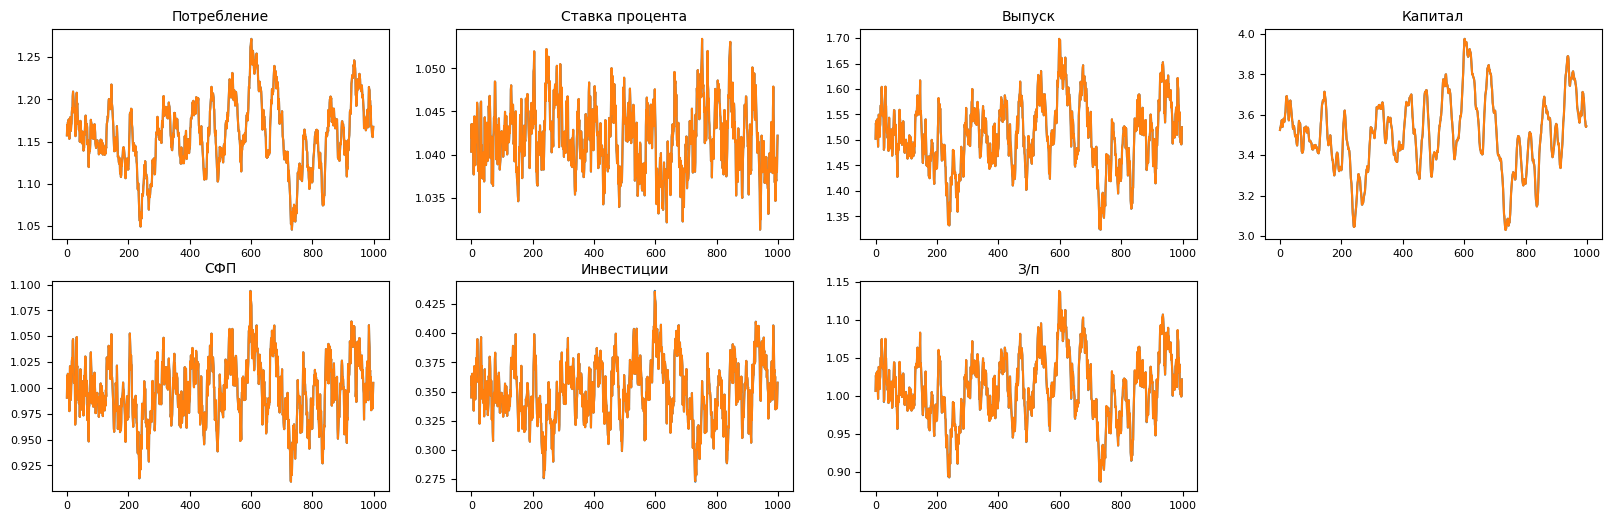

In [ ]:
plt.figure(figsize=(20, 6))

k_store_nn = np.reshape(k_list, (len(k_list),-1))
X_nn_init = np.dstack([(k_store_nn[:-1, ]-kss).flatten(), (z_list[:-1, ]-zss).flatten(), e_list[1:, ].flatten()])[0]
X_nn_init = tf.convert_to_tensor(X_nn_init, dtype = tf.float32)

opt_correct_z = tf.reshape(tf.convert_to_tensor(z_list[1:, ], dtype = tf.float32), shape=(len(z_list[1:, ]),1))
opt_correct_k = tf.reshape(tf.convert_to_tensor(k_list[1:, ], dtype = tf.float32), shape=(len(k_list[1:, ]),1))
opt_correct_c = tf.reshape(tf.convert_to_tensor(c_list[1:, ], dtype = tf.float32), shape=(len(c_list[1:, ]),1))
opt_correct_r = tf.reshape(tf.convert_to_tensor(r_list[1:, ], dtype = tf.float32), shape=(len(r_list[1:, ]),1))
opt_correct_y = tf.reshape(tf.convert_to_tensor(y_list[1:, ], dtype = tf.float32), shape=(len(y_list[1:, ]),1))
opt_correct_i = tf.reshape(tf.convert_to_tensor(i_list[1:, ], dtype = tf.float32), shape=(len(i_list[1:, ]),1))
opt_correct_w = tf.reshape(tf.convert_to_tensor(w_list[1:, ], dtype = tf.float32), shape=(len(w_list[1:, ]),1))

plt.subplot(241)
plt.plot(opt_correct_c.numpy())
plt.plot(mlp_model_c(X_nn_init).numpy())
plt.title('Потребление')

plt.subplot(242)
plt.plot(opt_correct_r.numpy())
plt.plot(mlp_model_r(X_nn_init).numpy())
plt.title('Ставка процента')

plt.subplot(243)
plt.plot(opt_correct_y.numpy())
plt.plot(mlp_model_y(X_nn_init).numpy())
plt.title('Выпуск')

plt.subplot(244)
plt.plot(opt_correct_k.numpy())
plt.plot(mlp_model_k(X_nn_init).numpy())
plt.title('Капитал')

plt.subplot(245)
plt.plot(opt_correct_z.numpy())
plt.plot(mlp_model_z(X_nn_init).numpy())
plt.title('СФП')


plt.subplot(246)
plt.plot(opt_correct_i.numpy())
plt.plot(mlp_model_i(X_nn_init).numpy())
plt.title('Инвестиции')

plt.subplot(247)
plt.plot(opt_correct_w.numpy())
plt.plot(mlp_model_w(X_nn_init).numpy())
plt.title('З/п')


plt.show()

iter: 1000/1503


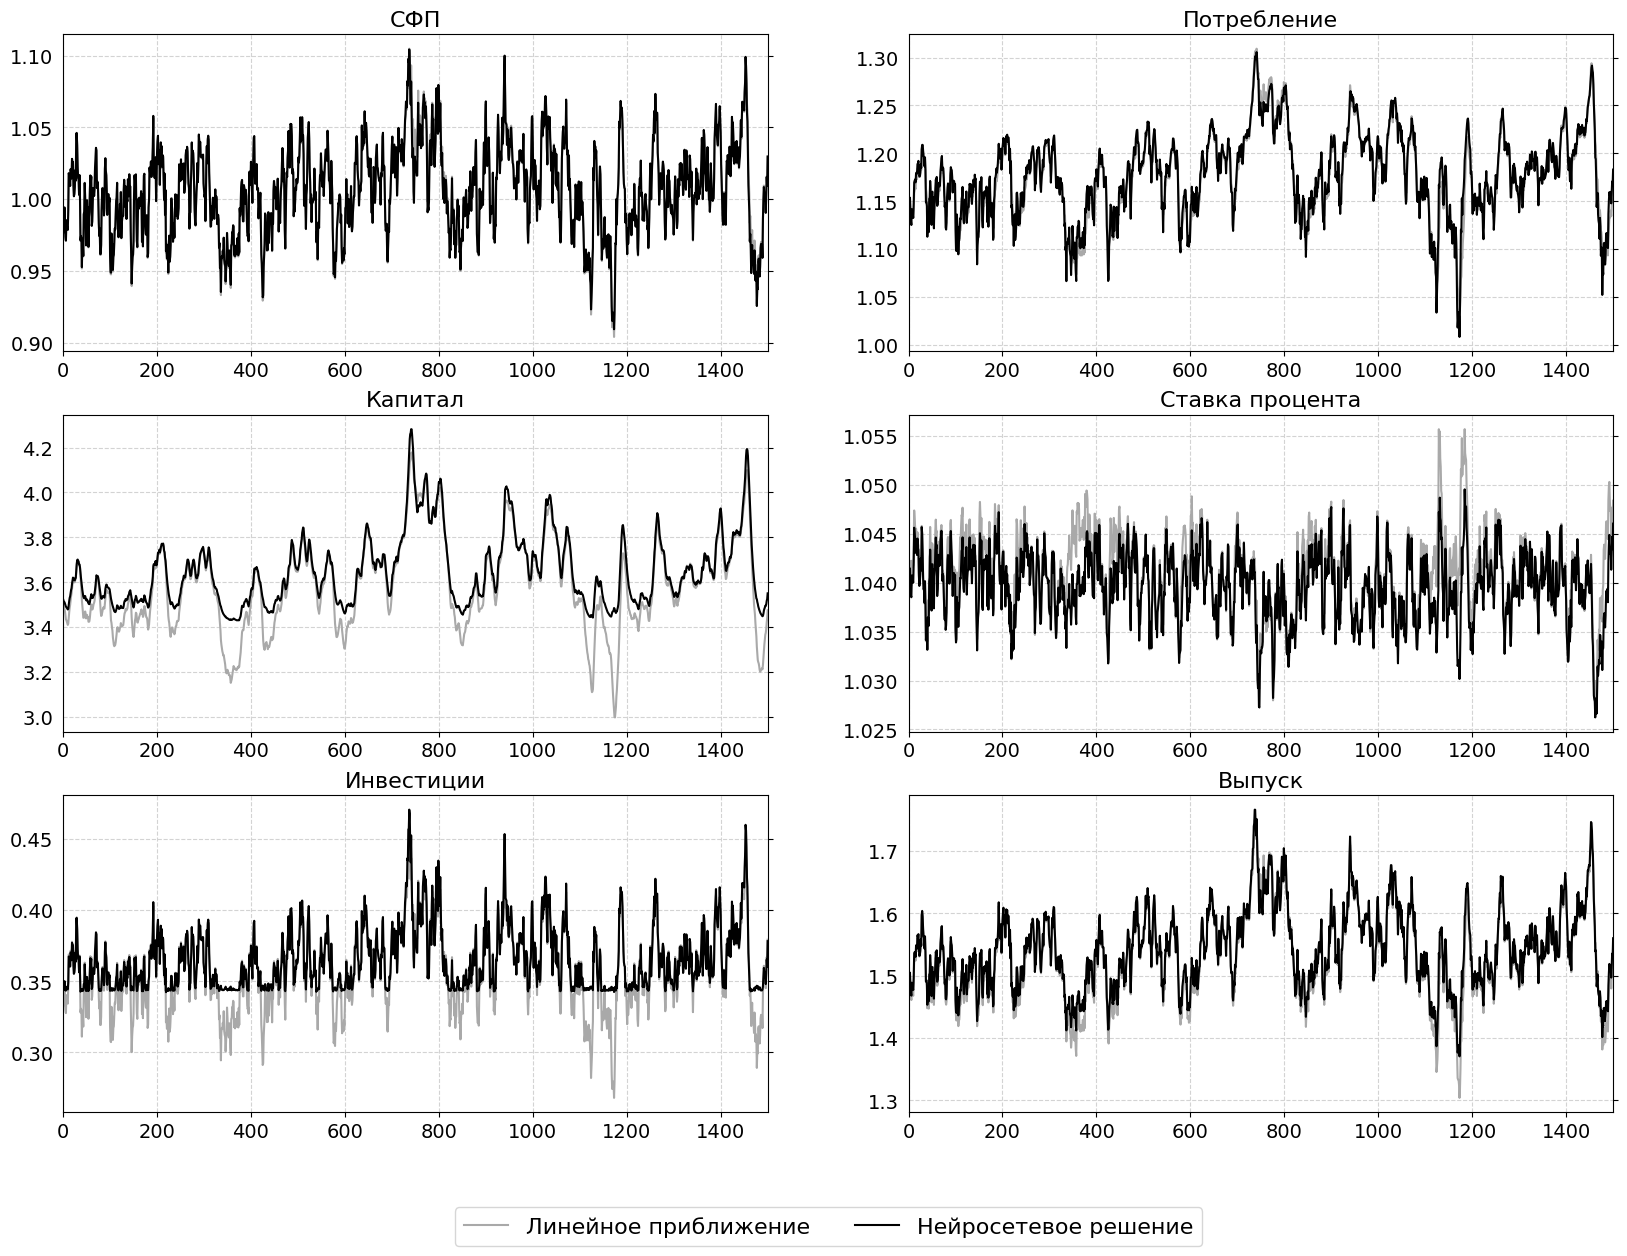

In [ ]:
T_plot=1503;
e1_plot=np.reshape(np.random.normal(loc=0.0, scale=stde, size=T_plot), (T_plot, 1))
z_plot=np.zeros((T_plot,1));
z_plot[0]=zss;
for i in range(1,T_plot):
  z_plot[i] = 1 + 0.90*(z_plot[i-1]-1.000) + 1.0*e1_plot[i]


k1=kss;
z1=zss;
c1_list = []
k1_list = []
r1_list = []
z1_list = []
i1_list = []
y1_list = []
w1_list = []
mu1_list = []


k1_lin = np.zeros((T_plot,1))
c1_lin = np.zeros((T_plot,1))
w1_lin = np.zeros((T_plot,1))
y1_lin = np.zeros((T_plot,1))
i1_lin = np.zeros((T_plot,1))
r1_lin = np.zeros((T_plot,1))
k1_lin[0] = kss


for t in range(1,T_plot):

  # Neural
  X_nn = [np.array([k1-kss]), np.array([z1-zss]), e1_plot[t]]
  X_nn = tf.convert_to_tensor(X_nn, dtype = tf.float32)
  X_nn = tf.reshape(X_nn, shape=(-1, len(X_nn)))
  c1 = mlp_model_c1(X_nn)
  r1 = mlp_model_r1(X_nn)
  k1_new = mlp_model_k1(X_nn)
  z_new = mlp_model_z1(X_nn)
  i1_new = mlp_model_i1(X_nn)
  y1_new = mlp_model_y1(X_nn)
  w1_new = mlp_model_w1(X_nn)
  mu1 = mlp_model_mu1(X_nn)

  c1_list.append(c1.numpy().flatten()[0])
  k1_list.append(k1_new.numpy().flatten()[0])
  r1_list.append(r1.numpy().flatten()[0])
  z1_list.append(z_new.numpy().flatten()[0])
  i1_list.append(i1_new.numpy().flatten()[0])
  w1_list.append(w1_new.numpy().flatten()[0])
  y1_list.append(y1_new.numpy().flatten()[0])
  mu1_list.append(mu1.numpy().flatten()[0])

  k1 = k1_new.numpy().flatten()[0]
  z1 = z_new.numpy().flatten()[0]

  # Linear
  k1_lin[t] = 3.532879   + 0.902615*(k1_lin[t-1]-3.53288) + 0.789497*(z_plot[t-1]-1.000) + 0.877219*e1_plot[t]
  y1_lin[t] = 1.516640   + 0.141667*(k1_lin[t-1]-3.53288) + 1.364976*(z_plot[t-1]-1.000) + 1.516640*e1_plot[t]
  c1_lin[t] = 1.163352   + 0.139052*(k1_lin[t-1]-3.53288) + 0.575479*(z_plot[t-1]-1.000) + 0.639421*e1_plot[t]
  r1_lin[t] = 1.041667   - 0.026867*(k1_lin[t-1]-3.53288) + 0.127500*(z_plot[t-1]-1.000) + 0.141667*e1_plot[t]
  i1_lin[t] = 0.353288   + 0.002615*(k1_lin[t-1]-3.53288) + 0.789497*(z_plot[t-1]-1.000) + 0.877219*e1_plot[t]
  y1_lin[t] = 1.516640   + 0.141667*(k1_lin[t-1]-3.53288) + 1.364976*(z_plot[t-1]-1.000) + 1.516640*e1_plot[t]
  w1_lin[t] = 1.016149   + 0.094917*(k1_lin[t-1]-3.53288) + 0.914534*(z_plot[t-1]-1.000) + 1.016149*e1_plot[t]


  if t%1000 == 0:
    print('iter: {}/{}'.format(t,T_plot))
ftitle=16
ftick=14

fig, axs = plt.subplots(3,2, figsize=(20,14))
axs[0,0].plot(z_plot[2:T_plot+1], color = 'darkgray')
axs[0,0].plot(z1_list[1:T_plot], color = 'black')
axs[0,0].tick_params(right=True, left=False, axis='y', labelsize=ftick)
axs[0,0].tick_params(axis='x', labelsize=ftick)
axs[0,0].grid(True, linestyle='--', color='lightgray')
axs[0,0].margins(x=0)
axs[0,0].set_title('СФП', size=ftitle)

axs[0,1].plot(c1_lin[2:T_plot+1], color = 'darkgray')
axs[0,1].plot(c1_list[1:T_plot], color = 'black')
axs[0,1].tick_params(right=True, left=False, axis='y', labelsize=ftick)
axs[0,1].tick_params(axis='x', labelsize=ftick)
axs[0,1].grid(True, linestyle='--', color='lightgray')
axs[0,1].margins(x=0)
axs[0,1].set_title('Потребление', size=ftitle)

axs[1,0].plot(k1_lin[2:T_plot+1], color = 'darkgray')
axs[1,0].plot(k1_list[1:T_plot], color = 'black')
axs[1,0].tick_params(right=True, left=False, axis='y', labelsize=ftick)
axs[1,0].tick_params(axis='x', labelsize=ftick)
axs[1,0].grid(True, linestyle='--', color='lightgray')
axs[1,0].margins(x=0)
axs[1,0].set_title('Капитал', size=ftitle)

axs[1,1].plot(r1_lin[2:T_plot+1], color = 'darkgray', label='Линейное приближение')
axs[1,1].plot(r1_list[1:T_plot], color = 'black', label='Нейросетевое решение')
axs[1,1].tick_params(right=True, left=False, axis='y', labelsize=ftick)
axs[1,1].tick_params(axis='x', labelsize=ftick)
axs[1,1].grid(True, linestyle='--', color='lightgray')
axs[1,1].margins(x=0)
axs[1,1].set_title('Ставка процента', size=ftitle)

axs[2,0].plot(i1_lin[2:T_plot+1], color = 'darkgray')
# axs[2,0].axhline(y=phi*iss, linestyle='--', color='r')
axs[2,0].plot(i1_list[1:T_plot], color = 'black')
axs[2,0].tick_params(right=True, left=False, axis='y', labelsize=ftick)
axs[2,0].tick_params(axis='x', labelsize=ftick)
axs[2,0].grid(True, linestyle='--', color='lightgray')
axs[2,0].margins(x=0)
axs[2,0].set_title('Инвестиции', size=ftitle)

axs[2,1].plot(y1_lin[2:T_plot+1], color = 'darkgray')
axs[2,1].plot(y1_list[1:T_plot], color = 'black')
axs[2,1].tick_params(right=True, left=False, axis='y', labelsize=ftick)
axs[2,1].tick_params(axis='x', labelsize=ftick)
axs[2,1].grid(True, linestyle='--', color='lightgray')
axs[2,1].margins(x=0)
axs[2,1].set_title('Выпуск', size=ftitle)
# axs[3,0].plot(w1_lin[1:T_plot], color = 'darkgray')
# axs[3,0].plot(w1_list[1:T_plot], color = 'black')
# axs[3,0].set_title('Заработная плата')
# axs[3,1].set_axis_off()
fig.legend(bbox_to_anchor=(0.7, 0.05),ncols=2, fontsize=16)

plt.savefig('/content/drive/MyDrive/RBCII_simul_ART1.png')

plt.show()

In [ ]:
print('Mean       Linear       ANN')
print('z:        {}    {:.6f}'.format(round(np.mean(z_plot[1:T_plot]),6), round(np.mean(z1_list[1:T_plot]),6)))
print('c:        {}    {:.6f}'.format(round(np.mean(c1_lin[1:T_plot]),6), round(np.mean(c1_list[1:T_plot]),6)))
print('k:        {}    {:.6f}'.format(round(np.mean(k1_lin[1:T_plot]),6), round(np.mean(k1_list[1:T_plot]),6)))
print('r:        {}    {:.6f}'.format(round(np.mean(r1_lin[1:T_plot]),6), round(np.mean(r1_list[1:T_plot]),6)))
print('i:        {}    {:.6f}'.format(round(np.mean(i1_lin[1:T_plot]),6),  round(np.mean(i1_list[1:T_plot]),6)))
print('w:        {}    {:.6f}'.format(round(np.mean(w1_lin[1:T_plot]),6),  round(np.mean(w1_list[1:T_plot]),6)))
print('y:        {}    {:.6f}'.format(round(np.mean(y1_lin[1:T_plot]),6),  round(np.mean(y1_list[1:T_plot]),6)))

Mean       Linear       ANN
z:        0.998957    0.999285
c:        1.161444    1.165329
k:        3.523908    3.600089
r:        1.041759    1.039822
i:        0.35235    0.359827
w:        1.014242    1.021882
y:        1.513793    1.525157


In [ ]:
from scipy.stats import ttest_ind
ttest_ind(k1_lin[1:T_plot], k1_list[1:T_plot], equal_var=False)

Ttest_indResult(statistic=array([-23.83391253]), pvalue=array([9.57373926e-122]))

In [ ]:
from scipy import stats

#k2, p = stats.normaltest(k1_lin[1:T_plot])
k2, p = stats.normaltest(k1_list[1:T_plot])

print("p = {}".format(p))

p = 9.31329911446386e-205


## Model solution

In [ ]:
wquad = np.pi**(-1/2)*np.array([0.2954, 1.1816, 0.2954]);
pquad = np.sqrt(2)*stde*np.array([-1.225, 0.0, 1.225]); # дискретизация нормального распределения на З точки

#### FOC

In [ ]:
def FOCs_onesectormodel(v, k_lag, z_lag, e, alpha, beta, depr, zss, rho, sigma, wquad, pquad,
                        mlp_model_c, mlp_model_r, mlp_model_mu):

  f_1 = 8
  F = np.empty((f_1,))

  c = v[0,]
  r = v[1,]
  y = v[2,]
  k = v[3,]
  z = v[4,]
  i = v[5,]
  w = v[6,]
  mu = v[7,]


  e_p = pquad;
  X_nn = tf.stack([tf.cast(tf.fill((len(e_p)), k-kss),tf.float64), tf.cast(tf.fill((len(e_p)), z-zss),tf.float64), tf.reshape(tf.convert_to_tensor(e_p), (len(e_p)))], axis=1)
  c_p = mlp_model_c(X_nn).numpy()
  r_p = mlp_model_r(X_nn).numpy()
  mu_p = mlp_model_mu(X_nn).numpy()

  F[0] = y  - (z*k_lag**alpha*1**(1-alpha))
  F[1] = y - c - i
  F[3] = w - ((1-alpha)*y)
  F[2] = np.log(z) - (rho*np.log(z_lag) + e)
  F[4] = r - (alpha*y/k_lag+1-depr)
  F[5] = k - (1-depr)*k_lag - i
  F[6] = np.dot(wquad,c**(-sigma) - mu - (beta*(c_p**(-sigma)*r_p - mu_p*(1-depr))))
  F[7] = (i-phi*iss) + mu - np.sqrt((i-phi*iss)**2 + mu**2) # Fisher-Burmeister

  return (F)

In [ ]:
pss = np.array([css, rss, yss, kss, zss, iss, wss, 0.001])
p = np.empty((T,8))


# Solve system of nonlinear equations
for t in range(1,50):
  if t%10==0:
    print("iter ", t)
  k_lag = k_list[t-1]
  z_lag = z_list[t-1]
  e = e_list[t]

  sol = fsolve(FOCs_onesectormodel, x0 = pss, args=(k_lag, z_lag, e, alpha, beta, depr, zss, rho, sigma, wquad, pquad,
                                                    mlp_model_c, mlp_model_r, mlp_model_mu), col_deriv=True, xtol=1e-10, maxfev=5000)
  # sol = root(FOCs_onesectormodel, x0 = pss, args=(k_lag, z_lag, e, alpha, beta, depr, zss, rho, sigma, wquad, pquad,
  #                                               mlp_model_c, mlp_model_r, mlp_model_k, mlp_model_mu),
  #           method='lm', tol=1e-10, options={'col_deriv': True, 'maxiter': 5000, 'ftol': 1e-10, 'xtol' :1e-8})


  #sol = least_squares(FOCs_onesectormodel, x0=pss, args=(k_lag, z_lag, e, alpha, beta, depr, zss, rho,
  #                                                       sigma, wquad, pquad,mlp_model_c, mlp_model_r, mlp_model_k,
  #                                                       mlp_model_i),
  #                    jac='2-point', method='lm',
  #                    ftol=1e-15, xtol=1e-15,
  #                    gtol=1e-10, x_scale=1.0, loss='linear', f_scale=1.0, tr_solver=None, verbose=0)



  p[t,:] = sol

/usr/local/lib/python3.10/dist-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


iter  10
iter  20
iter  30
iter  40


In [ ]:
sol

array([1.11477   , 1.04660455, 1.4592257 , 3.30063982, 0.98555555,
       0.34445569, 0.97768122, 0.00789467])

In [ ]:
np.isclose(FOCs_onesectormodel(sol,k_lag, z_lag, e, alpha, beta, depr, zss, rho, sigma, wquad, pquad,
                               mlp_model_c, mlp_model_r, mlp_model_mu),
           [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

array([ True,  True,  True,  True,  True,  True,  True,  True])

In [ ]:
FOCs_onesectormodel(sol,k_lag, z_lag, e, alpha, beta, depr, zss, rho, sigma, wquad, pquad,
                    mlp_model_c, mlp_model_r, mlp_model_mu)

array([0.00000000e+00, 1.66533454e-16, 5.20417043e-18, 0.00000000e+00,
       0.00000000e+00, 1.66533454e-16, 9.93380564e-09, 2.22044605e-16])

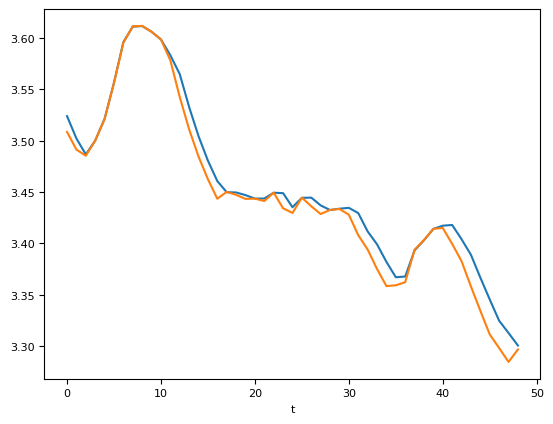

In [ ]:
plt.plot(p[1:50,3])
#plt.plotp[1:50,5])**2+phi*iss)
plt.plot(k_list[1:50])
plt.xlabel('t')
plt.show()

In [ ]:
pss = np.array([css, rss, yss, kss, zss, iss, wss, 0.001])
p = np.empty((T,8))

time_start = datetime.now()

mse=tf.keras.losses.MeanSquaredError()

print('start time: {}'.format(time_start))

for j in range (10):
  print()
  print('********* j = {} *********'.format(j))

  #Solve system of nonlinear equations
  for t in range(1,T):
    k_lag = k_list[t-1]
    z_lag = z_list[t-1]
    e = e_list[t]

    sol = fsolve(FOCs_onesectormodel, x0 = pss, args=(k_lag, z_lag, e, alpha, beta, depr, zss, rho, sigma, wquad, pquad,
                                                      mlp_model_c, mlp_model_r, mlp_model_mu),
                  xtol=1e-10, maxfev=5000)
    # sol = root(FOCs_onesectormodel, x0 = pss, args=(k_lag, z_lag, e, alpha, beta, depr, zss, rho, sigma, wquad, pquad,
    #                                              mlp_model_c, mlp_model_r, mlp_model_k, mlp_model_mu),
    #          method='lm', tol=1e-10, options={'col_deriv': True, 'maxiter': 5000, 'ftol': 1e-10, 'xtol' :1e-8})


    p[t,:] = sol #c, r, y, k, z, i, w

    if t%200==0:
      print('iteration: {};     time since start: {}'.format(t,datetime.now()-time_start))
      print(np.round(sol,4))


  #Redefine NN

  # mlp_model_c = Sequential()
  # mlp_model_c.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  # mlp_model_c.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  # mlp_model_c.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))
  # mlp_model_c.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])

  mlp_model_r = Sequential()
  mlp_model_r.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_r.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_r.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))
  mlp_model_r.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])

  mlp_model_y = Sequential()
  mlp_model_y.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_y.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_y.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))
  mlp_model_y.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])

  # mlp_model_k = Sequential()
  # mlp_model_k.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
  # mlp_model_k.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
  # mlp_model_k.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))#, kernel_regularizer=regularizers.l2(0.001)))
  # mlp_model_k.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['mse'])

  # mlp_model_A = Sequential()
  # mlp_model_A.add(Dense(72, kernel_initializer='he_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
  # mlp_model_A.add(Dense(72, kernel_initializer='he_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
  # mlp_model_A.add(Dense(1, kernel_initializer='he_uniform', bias_initializer="he_uniform", activation='softplus'))#, kernel_regularizer=regularizers.l2(0.001)))
  # mlp_model_A.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.02), metrics=['mse'])

  mlp_model_l = Sequential()
  mlp_model_l.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_l.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_l.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))
  mlp_model_l.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])

  mlp_model_i = Sequential()
  mlp_model_i.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_i.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_i.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))
  mlp_model_i.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), metrics=['mse'])

  mlp_model_w = Sequential()
  mlp_model_w.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_w.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_w.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))
  mlp_model_w.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])

  mlp_model_mu = Sequential()
  mlp_model_mu.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_mu.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
  mlp_model_mu.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))
  mlp_model_mu.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])


  # Start training

  X_nn_train = tf.reshape(tf.convert_to_tensor(np.stack([k_list[0:T-1]-kss,z_list[0:T-1]-zss,e_list[1:T]],axis=1), dtype = tf.float32), (T-1,3))

  opt_correct_z = tf.reshape(tf.convert_to_tensor(p[1:,4:5], dtype = tf.float32), shape=(len(p[1:,4:5]),-1))
  opt_correct_k = tf.reshape(tf.convert_to_tensor(p[1:,3:4], dtype = tf.float32), shape=(len(p[1:,3:4]),-1))
  opt_correct_c = tf.reshape(tf.convert_to_tensor(p[1:,:1], dtype = tf.float32), shape=(len(p[1:,:1]),-1))
  opt_correct_r = tf.reshape(tf.convert_to_tensor(p[1:,1:2], dtype = tf.float32), shape=(len(p[1:,1:2]),-1))
  opt_correct_y = tf.reshape(tf.convert_to_tensor(p[1:,2:3], dtype = tf.float32), shape=(len(p[1:,2:3]),-1))
  opt_correct_i = tf.reshape(tf.convert_to_tensor(p[1:,5:6], dtype = tf.float32), shape=(len(p[1:,5:6]),-1))
  opt_correct_w = tf.reshape(tf.convert_to_tensor(p[1:,6:7], dtype = tf.float32), shape=(len(p[1:,6:7]),-1))
  opt_correct_mu = tf.reshape(tf.convert_to_tensor(p[1:,7:], dtype = tf.float32), shape=(len(p[1:,7:]),-1))

  mse=tf.keras.losses.MeanSquaredError()

  callback = tf.keras.callbacks.EarlyStopping(monitor='loss', patience=5000, baseline = 0, restore_best_weights=True, start_from_epoch=2000)

  loss_k_list = []
  for j in range(2):
    mlp_model_k = Sequential()
    mlp_model_k.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
    mlp_model_k.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
    mlp_model_k.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))#, kernel_regularizer=regularizers.l2(0.001)))
    mlp_model_k.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.02), metrics=['mse'])
    mlp_model_k.fit(X_nn_train, opt_correct_k, verbose=0, epochs=40000, batch_size=T, callbacks=[callback])
    loss_k = mlp_model_k.evaluate(X_nn_train, opt_correct_k, verbose=0)[0]
    #print('loss k: ', loss_k)
    loss_k_list.append(loss_k)
    if loss_k==np.min(loss_k_list):
      reserved_model_k = mlp_model_k
  mlp_model_k = reserved_model_k
  print('model for k finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_k.evaluate(X_nn_train, opt_correct_k, verbose=0)[0], datetime.now()-time_start))

  loss_z_list = []
  for j in range(2):
    mlp_model_z = Sequential()
    mlp_model_z.add(Dense(72, kernel_initializer='he_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
    mlp_model_z.add(Dense(72, kernel_initializer='he_uniform', bias_initializer="he_uniform", activation='swish'))#, kernel_regularizer=regularizers.l2(0.001)))
    mlp_model_z.add(Dense(1, kernel_initializer='he_uniform', bias_initializer="he_uniform", activation='softplus'))#, kernel_regularizer=regularizers.l2(0.001)))
    mlp_model_z.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.02), metrics=['mse'])
    mlp_model_z.fit(X_nn_train, opt_correct_z, verbose=0, epochs=30000, batch_size=T, callbacks=[callback])
    loss_z = mlp_model_z.evaluate(X_nn_train, opt_correct_z, verbose=0)[0]
    #print('loss z: ', loss_z)
    loss_z_list.append(loss_z)
    if loss_z==np.min(loss_z_list):
      reserved_model_z = mlp_model_z
  mlp_model_z = reserved_model_z
  print('model for z finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_z.evaluate(X_nn_train, opt_correct_z, verbose=0)[0], datetime.now()-time_start))

  loss_c_list = []
  for j in range(2):
    mlp_model_c = Sequential()
    mlp_model_c.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
    mlp_model_c.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
    mlp_model_c.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='softplus'))
    mlp_model_c.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), metrics=['mse'])
    mlp_model_c.fit(X_nn_train, opt_correct_c, verbose=0, epochs=20000, batch_size=T, callbacks=[callback])
    loss_c = mlp_model_c.evaluate(X_nn_train, opt_correct_c, verbose=0)[0]
    #print('loss c: ', loss_c)
    loss_c_list.append(loss_c)
    if loss_c==np.min(loss_c_list):
      reserved_model_c = mlp_model_c
  mlp_model_c = reserved_model_c
  print('model for c finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_c.evaluate(X_nn_train, opt_correct_c, verbose=0)[0], datetime.now()-time_start))
  mlp_model_r.fit(X_nn_train, opt_correct_r, verbose=0, epochs=20000, batch_size=T, callbacks=[callback])
  print('model for r finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_r.evaluate(X_nn_train, opt_correct_r, verbose=0)[0], datetime.now()-time_start))
  mlp_model_y.fit(X_nn_train, opt_correct_y, verbose=0, epochs=12000, batch_size=T, callbacks=[callback])
  print('model for y finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_y.evaluate(X_nn_train, opt_correct_y, verbose=0)[0], datetime.now()-time_start))
  mlp_model_i.fit(X_nn_train, opt_correct_i, verbose=0, epochs=40000, batch_size=T, callbacks=[callback])
  print('model for i finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_i.evaluate(X_nn_train, opt_correct_i, verbose=0)[0], datetime.now()-time_start))
  mlp_model_w.fit(X_nn_train, opt_correct_w, verbose=0, epochs=12000, batch_size=T, callbacks=[callback])
  print('model for w finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_w.evaluate(X_nn_train, opt_correct_w, verbose=0)[0], datetime.now()-time_start))
  mlp_model_mu.fit(X_nn_train, opt_correct_mu, verbose=0, epochs=20000, batch_size=T, callbacks=[callback])
  print('model for mu finished training. loss: {}, ---- time sinse start: {}'.format(mlp_model_mu.evaluate(X_nn_train, opt_correct_mu, verbose=0)[0], datetime.now()-time_start))


  T_irf=80;
  e_list_plot=np.reshape(np.random.uniform(0, 0, size=T_irf), (T_irf, 1))
  e_list_plot[1] = -0.04 #stde

  z_list_plot=np.zeros((T_irf,1));
  z_list_plot[0]=zss;

  k_list_plot=np.zeros((T_irf,1));
  k_list_plot[0]=kss;

  y_list_plot=np.zeros((T_irf,1));
  y_list_plot[0]=yss;

  c_list_plot=np.zeros((T_irf,1));
  c_list_plot[0]=css;

  i_list_plot=np.zeros((T_irf,1));
  i_list_plot[0]=iss;

  w_list_plot=np.zeros((T_irf,1));
  w_list_plot[0]=wss;

  r_list_plot=np.zeros((T_irf,1));
  r_list_plot[0]=rss;

  for i in range(1,T_irf):
    k_list_plot[i] = 3.532879   + 0.902615*(k_list_plot[i-1]-3.53288) + 0.789497*(z_list_plot[i-1]-1.000) + 0.877219*e_list_plot[i]
    z_list_plot[i] = 1          +                                           0.90*(z_list_plot[i-1]-1.000) + 1.000000*e_list_plot[i]
    y_list_plot[i] = 1.516640   + 0.141667*(k_list_plot[i-1]-3.53288) + 1.364976*(z_list_plot[i-1]-1.000) + 1.516640*e_list_plot[i]
    c_list_plot[i] = 1.163352   + 0.139052*(k_list_plot[i-1]-3.53288) + 0.575479*(z_list_plot[i-1]-1.000) + 0.639421*e_list_plot[i]
    i_list_plot[i] = 0.353288   + 0.002615*(k_list_plot[i-1]-3.53288) + 0.789497*(z_list_plot[i-1]-1.000) + 0.877219*e_list_plot[i]
    w_list_plot[i] = 1.016149   + 0.094917*(k_list_plot[i-1]-3.53288) + 0.914534*(z_list_plot[i-1]-1.000) + 1.016149*e_list_plot[i]
    r_list_plot[i] = 1.041667   - 0.026867*(k_list_plot[i-1]-3.53288) + 0.127500*(z_list_plot[i-1]-1.000) + 0.141667*e_list_plot[i]

  c1_list_plot = np.zeros((T_irf,1));
  k1_list_plot = np.zeros((T_irf,1));
  y1_list_plot = np.zeros((T_irf,1));
  i1_list_plot = np.zeros((T_irf,1));
  r1_list_plot = np.zeros((T_irf,1));
  w1_list_plot = np.zeros((T_irf,1));
  z1_list_plot = np.zeros((T_irf,1));

  k1_list_plot[0] = kss
  z1_list_plot[0] = zss
  c1_old = css

  for t in range(1,T_irf):

    X_nn_irf = tf.reshape(tf.convert_to_tensor(np.stack([np.array([k1_list_plot[t-1]-kss]).flatten(),z1_list_plot[t-1]-zss,e_list_plot[t]],axis=1), dtype = tf.float32), (-1,3))
    pred_c_irf = mlp_model_c(X_nn_irf)
    pred_r_irf = mlp_model_r(X_nn_irf)
    pred_y_irf = mlp_model_y(X_nn_irf)
    pred_k_irf = mlp_model_k(X_nn_irf)
    pred_z_irf = mlp_model_z(X_nn_irf)
    pred_i_irf = mlp_model_i(X_nn_irf)
    pred_w_irf = mlp_model_w(X_nn_irf)

    c1_list_plot[t] = pred_c_irf.numpy().flatten()
    r1_list_plot[t] = pred_r_irf.numpy().flatten()
    y1_list_plot[t] = pred_y_irf.numpy().flatten()
    k1_list_plot[t] = pred_k_irf.numpy().flatten()
    z1_list_plot[t] = pred_z_irf.numpy().flatten()
    i1_list_plot[t] = pred_i_irf.numpy().flatten()
    w1_list_plot[t] = pred_w_irf.numpy().flatten()


  fig, axs = plt.subplots(3,3, figsize=(8,5))
  fig.tight_layout(pad=2.0)
  plt.rc('axes', titlesize=10)
  plt.rc('axes', labelsize=8)
  plt.rc('xtick', labelsize=8)
  plt.rc('ytick', labelsize=8)

  axs[0,0].plot(np.array((y1_list_plot[1:]-yss)/yss))
  axs[0,0].plot(np.array((y_list_plot[1:]-yss)/yss))
  axs[0,0].axhline(y=0, color='r')
  axs[0,0].set_title('y')

  axs[0,1].plot(np.array((c1_list_plot[1:]-css)/css))
  axs[0,1].plot(np.array((c_list_plot[1:]-css)/css))
  axs[0,1].axhline(y=0, color='r')
  axs[0,1].set_title('c')

  axs[0,2].plot(np.array((i1_list_plot[1:]-iss)/iss))
  axs[0,2].plot(np.array((i_list_plot[1:]-iss)/iss))
  axs[0,2].axhline(y=0, color='r')
  axs[0,2].set_title('i')

  axs[1,0].plot(np.array((k1_list_plot[1:]-kss)/kss))
  axs[1,0].plot(np.array((k_list_plot[1:]-kss)/kss))
  axs[1,0].axhline(y=0, color='r')
  axs[1,0].set_title('k')

  axs[1,1].plot(np.array((z1_list_plot[1:]-zss)/zss))
  axs[1,1].plot(np.array((z_list_plot[1:]-zss)/zss))
  axs[1,1].axhline(y=0, color='r')
  axs[1,1].set_title('z')


  axs[2,0].plot(np.array((w1_list_plot[1:]-wss)/wss))
  axs[2,0].plot(np.array((w_list_plot[1:]-wss)/wss))
  axs[2,0].axhline(y=0, color='r')
  axs[2,0].set_title('w')

  axs[2,1].plot(np.array((r1_list_plot[1:]-rss)/rss))
  axs[2,1].plot(np.array((r_list_plot[1:]-rss)/rss))
  axs[2,1].axhline(y=0, color='r')
  axs[2,1].set_title('r')

  axs[2,2].axis('off')

  #plt.savefig('/content/drive/MyDrive/RBCII_IRF.png')

  plt.show()

start time: 2025-04-09 16:10:38.701096

********* j = 0 *********


<ipython-input-8-e681452b0b51>:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F[0] = y  - (z*k_lag**alpha*1**(1-alpha))
<ipython-input-8-e681452b0b51>:26: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F[2] = np.log(z) - (rho*np.log(z_lag) + e)
<ipython-input-8-e681452b0b51>:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  F[4] = r - (alpha*y/k_lag+1-depr)
<ipython-input-8-e681452b0b51>:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is 

iteration: 200;     time since start: 0:02:04.378221
[ 1.2     1.0379  1.5647  3.7345  1.0121  0.3647  1.0483 -0.    ]
iteration: 400;     time since start: 0:03:53.829151
[1.1517 1.0446 1.5073 3.452  1.0026 0.3556 1.0099 0.    ]
iteration: 600;     time since start: 0:05:43.109395
[1.1487 1.0369 1.4932 3.5832 0.9786 0.3445 1.0004 0.014 ]
iteration: 800;     time since start: 0:07:41.868143
[1.1385 1.0393 1.483  3.5053 0.9797 0.3445 0.9936 0.0122]


KeyboardInterrupt: 

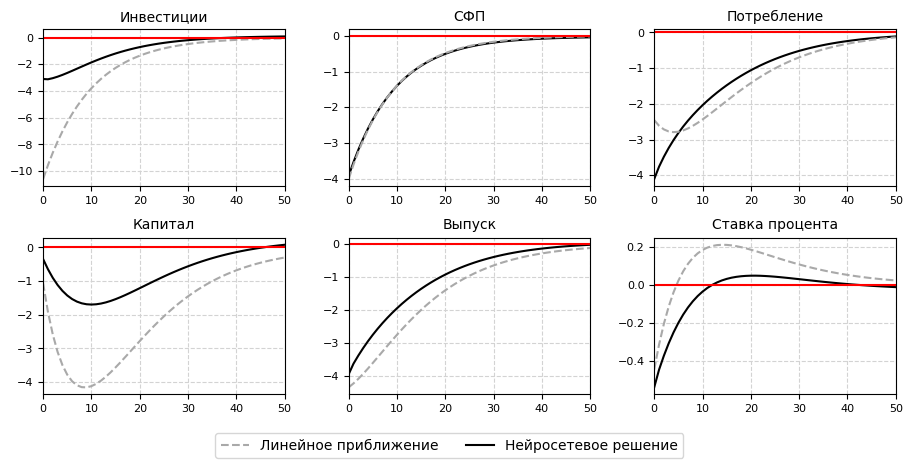

In [ ]:
T_irf=52;
e_list_plot=np.reshape(np.random.uniform(0, 0, size=T_irf), (T_irf, 1))
e_list_plot[1] = -0.04 #stde

z_list_plot=np.zeros((T_irf,1));
z_list_plot[0]=zss;

k_list_plot=np.zeros((T_irf,1));
k_list_plot[0]=kss;

y_list_plot=np.zeros((T_irf,1));
y_list_plot[0]=yss;

c_list_plot=np.zeros((T_irf,1));
c_list_plot[0]=css;

i_list_plot=np.zeros((T_irf,1));
i_list_plot[0]=iss;

w_list_plot=np.zeros((T_irf,1));
w_list_plot[0]=wss;

r_list_plot=np.zeros((T_irf,1));
r_list_plot[0]=rss;

for i in range(1,T_irf):
  k_list_plot[i] = 3.532879   + 0.902510*(k_list_plot[i-1]-3.53288) + 0.841969*(z_list_plot[i-1]-1.000) + 0.935521*e_list_plot[i]
  z_list_plot[i] = 1          +                                           0.90*(z_list_plot[i-1]-1.000) + 1.000000*e_list_plot[i]
  y_list_plot[i] = 1.516640   + 0.127856*(k_list_plot[i-1]-3.53288) + 1.484255*(z_list_plot[i-1]-1.000) + 1.649172*e_list_plot[i]
  c_list_plot[i] = 1.163352   + 0.125346*(k_list_plot[i-1]-3.53288) + 0.642286*(z_list_plot[i-1]-1.000) + 0.713651*e_list_plot[i]
  i_list_plot[i] = 0.353288   + 0.002510*(k_list_plot[i-1]-3.53288) + 0.841969*(z_list_plot[i-1]-1.000) + 0.935521*e_list_plot[i]
  w_list_plot[i] = 1.016149   + 0.085663*(k_list_plot[i-1]-3.53288) + 0.994451*(z_list_plot[i-1]-1.000) + 1.104945*e_list_plot[i]
  r_list_plot[i] = 1.041667   - 0.024247*(k_list_plot[i-1]-3.53288) + 0.104879*(z_list_plot[i-1]-1.000) + 0.116532*e_list_plot[i]

c1_list_plot = np.zeros((T_irf,1));
k1_list_plot = np.zeros((T_irf,1));
y1_list_plot = np.zeros((T_irf,1));
i1_list_plot = np.zeros((T_irf,1));
r1_list_plot = np.zeros((T_irf,1));
w1_list_plot = np.zeros((T_irf,1));
z1_list_plot = np.zeros((T_irf,1));

k1_list_plot[0] = kss
z1_list_plot[0] = zss
c1_old = css

for t in range(1,T_irf):

  X_nn_irf = tf.reshape(tf.convert_to_tensor(np.stack([np.array([k1_list_plot[t-1]-kss]).flatten(),z1_list_plot[t-1]-zss,e_list_plot[t]],axis=1), dtype = tf.float32), (-1,3))
  pred_c_irf = mlp_model_c(X_nn_irf)
  pred_r_irf = mlp_model_r(X_nn_irf)
  pred_y_irf = mlp_model_y(X_nn_irf)
  pred_k_irf = mlp_model_k(X_nn_irf)
  pred_z_irf = mlp_model_z(X_nn_irf)
  pred_i_irf = mlp_model_i(X_nn_irf)
  pred_w_irf = mlp_model_w(X_nn_irf)

  c1_list_plot[t] = pred_c_irf.numpy().flatten()
  r1_list_plot[t] = pred_r_irf.numpy().flatten()
  y1_list_plot[t] = pred_y_irf.numpy().flatten()
  k1_list_plot[t] = pred_k_irf.numpy().flatten()
  z1_list_plot[t] = pred_z_irf.numpy().flatten()
  i1_list_plot[t] = pred_i_irf.numpy().flatten()
  w1_list_plot[t] = pred_w_irf.numpy().flatten()


fig, axs = plt.subplots(2,3, figsize=(10,5))
fig.tight_layout(pad=4.0, h_pad=2.0, w_pad=2.0)
plt.rc('axes', titlesize=10)
plt.rc('axes', labelsize=8)
plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)

axs[1,1].plot(np.array((y1_list_plot[1:]-yss)/yss*100), color='black')
axs[1,1].plot(np.array((y_list_plot[1:]-yss)/yss*100), color='darkgray', linestyle='--')
axs[1,1].axhline(y=0, color='r')
axs[1,1].grid(True, linestyle='--', color='lightgray')
axs[1,1].margins(x=0)
axs[1,1].set_title('Выпуск')

axs[0,2].plot(np.array((c1_list_plot[1:]-css)/css*100), color='black')
axs[0,2].plot(np.array((c_list_plot[1:]-css)/css*100), color='darkgray', linestyle='--')
axs[0,2].axhline(y=0, color='r')
axs[0,2].grid(True, linestyle='--', color='lightgray')
axs[0,2].margins(x=0)
axs[0,2].set_title('Потребление')

axs[0,0].plot(np.array((i1_list_plot[1:]-iss)/iss*100), color='black')
axs[0,0].plot(np.array((i_list_plot[1:]-iss)/iss*100), color='darkgray', linestyle='--')
axs[0,0].axhline(y=0, color='r')
axs[0,0].grid(True, linestyle='--', color='lightgray')
axs[0,0].margins(x=0)
axs[0,0].set_title('Инвестиции')

axs[1,0].plot(np.array((k1_list_plot[1:]-kss)/kss*100), color='black')
axs[1,0].plot(np.array((k_list_plot[1:]-kss)/kss*100), color='darkgray', linestyle='--')
axs[1,0].axhline(y=0, color='r')
axs[1,0].grid(True, linestyle='--', color='lightgray')
axs[1,0].margins(x=0)
axs[1,0].set_title('Капитал')

axs[0,1].plot(np.array((z1_list_plot[1:]-zss)/zss*100), color='black')
axs[0,1].plot(np.array((z_list_plot[1:]-zss)/zss*100), color='darkgray', linestyle='--')
axs[0,1].axhline(y=0, color='r')
axs[0,1].grid(True, linestyle='--', color='lightgray')
axs[0,1].margins(x=0)
axs[0,1].set_title('СФП')


# axs[1,2].plot(np.array((w1_list_plot[1:]-wss)/wss*100), color='black')
# axs[1,2].plot(np.array((w_list_plot[1:]-wss)/wss*100), color='darkgray', linestyle='--')
# axs[1,2].axhline(y=0, color='r')
# axs[1,2].grid(True, linestyle='--', color='lightgray')
# axs[1,2].margins(x=0)
# axs[1,2].set_title('Заработная плата')

axs[1,2].plot(np.array((r_list_plot[1:]-rss)/rss*100), color='darkgray', linestyle='--', label='Линейное приближение')
axs[1,2].plot(np.array((r1_list_plot[1:]-rss)/rss*100), color='black', label='Нейросетевое решение')
axs[1,2].axhline(y=0, color='r')
axs[1,2].grid(True, linestyle='--', color='lightgray')
axs[1,2].margins(x=0)
axs[1,2].set_title('Ставка процента')

# axs[1,3].axis('off')
# axs[2,2].axis('off')
axs[1,2].legend(bbox_to_anchor=(0.15, -0.2),ncols=2, fontsize=10)
# fig.tight_layout(pad=2.0)

plt.savefig('/content/drive/MyDrive/RBCII_IRF_neg_ART.png')

plt.show()

In [ ]:
import numpy
numpy.savetxt("/content/drive/MyDrive/c_numpy_lm.csv", c_list)
numpy.savetxt("/content/drive/MyDrive/z_numpy_lm.csv", z_list)
numpy.savetxt("/content/drive/MyDrive/k_numpy_lm.csv", k_list)
numpy.savetxt("/content/drive/MyDrive/e_numpy_lm.csv", e_list)
numpy.savetxt("/content/drive/MyDrive/r_numpy_lm.csv", r_list)
numpy.savetxt("/content/drive/MyDrive/y_numpy_lm.csv", y_list)
numpy.savetxt("/content/drive/MyDrive/i_numpy_lm.csv", i_list)
numpy.savetxt("/content/drive/MyDrive/w_numpy_lm.csv", w_list)

In [ ]:
mlp_model_c.save('/content/drive/MyDrive/mlp_model_c_irr_ART.keras')
mlp_model_r.save('/content/drive/MyDrive/mlp_model_r_irr_ART.keras')
mlp_model_y.save('/content/drive/MyDrive/mlp_model_y_irr_ART.keras')
mlp_model_k.save('/content/drive/MyDrive/mlp_model_k_irr_ART.keras')
mlp_model_z.save('/content/drive/MyDrive/mlp_model_z_irr_ART.keras')
mlp_model_mu.save('/content/drive/MyDrive/mlp_model_mu_irr_ART.keras')
mlp_model_i.save('/content/drive/MyDrive/mlp_model_i_irr_ART.keras')
mlp_model_w.save('/content/drive/MyDrive/mlp_model_w_irr_ART.keras')

In [ ]:
import tf_keras

In [ ]:
mlp_model_c = tf_keras.models.load_model('/content/drive/MyDrive/mlp_model_c_irr') #sim_lm')
mlp_model_r = tf_keras.models.load_model('/content/drive/MyDrive/mlp_model_r_irr') #sim_lm')
mlp_model_y = tf_keras.models.load_model('/content/drive/MyDrive/mlp_model_y_irr') #sim_lm')
mlp_model_k = tf_keras.models.load_model('/content/drive/MyDrive/mlp_model_k_irr') #sim_lm')
mlp_model_z = tf_keras.models.load_model('/content/drive/MyDrive/mlp_model_z_irr') #sim_lm')
mlp_model_mu = tf_keras.models.load_model('/content/drive/MyDrive/mlp_model_mu_irr') #sim_lm')
mlp_model_i = tf_keras.models.load_model('/content/drive/MyDrive/mlp_model_i_irr') #sim_lm')
mlp_model_w = tf_keras.models.load_model('/content/drive/MyDrive/mlp_model_w_irr') #sim_lm')

In [ ]:
# Новые!
mlp_model_c1 = keras.models.load_model('/content/drive/MyDrive/mlp_model_c_irr_ART.keras') #sim_lm')
mlp_model_r1 = keras.models.load_model('/content/drive/MyDrive/mlp_model_r_irr_ART.keras') #sim_lm')
mlp_model_y1 = keras.models.load_model('/content/drive/MyDrive/mlp_model_y_irr_ART.keras') #sim_lm')
mlp_model_k1 = keras.models.load_model('/content/drive/MyDrive/mlp_model_k_irr_ART.keras') #sim_lm')
mlp_model_z1 = keras.models.load_model('/content/drive/MyDrive/mlp_model_z_irr_ART.keras') #sim_lm')
mlp_model_mu1 = keras.models.load_model('/content/drive/MyDrive/mlp_model_mu_irr_ART.keras') #sim_lm')
mlp_model_i1 = keras.models.load_model('/content/drive/MyDrive/mlp_model_i_irr_ART.keras') #sim_lm')
mlp_model_w1 = keras.models.load_model('/content/drive/MyDrive/mlp_model_w_irr_ART.keras') #sim_lm')

In [ ]:
model_c = Sequential()
model_c.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
model_c.add(Dense(72, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
model_c.add(Dense(1, kernel_initializer='glorot_uniform', bias_initializer="he_uniform", activation='swish'))
model_c.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), metrics=['mse'])
model_c.fit(X_nn_train, opt_correct_c, verbose=0, epochs=40000, batch_size=T, callbacks=[callback])
print('model for c finished training. loss: {}, ---- time sinse start: {}'.format(model_c.evaluate(X_nn_train, opt_correct_c, verbose=0)[0], datetime.now()-time_start))

model for c finished training. loss: 2.236673390143551e-05, ---- time sinse start: 0:32:09.540884


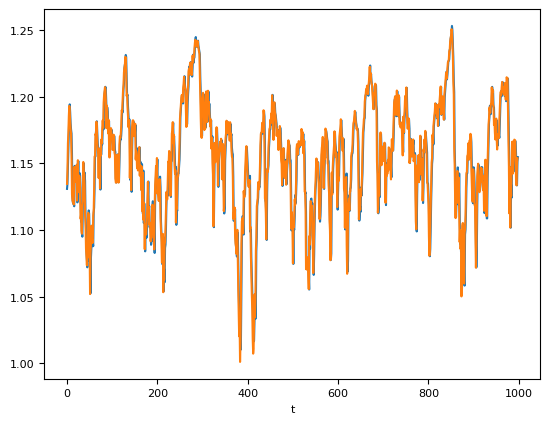

In [ ]:
#plt.plot(p[1:3000,4])
plt.plot((p[1:3000,0]))
plt.plot(mlp_model_c(X_nn_init)[1:3000])
#plt.plot(w_list[1:3000])
#plt.plot(p[1:3000,0])
plt.xlabel('t')
plt.show()

In [ ]:
mlp_model_c.save('/content/drive/MyDrive/NN_c.h5')
mlp_model_r.save('/content/drive/MyDrive/NN_r.h5')
mlp_model_y.save('/content/drive/MyDrive/NN_y.h5')
mlp_model_k.save('/content/drive/MyDrive/NN_k.h5')
mlp_model_z.save('/content/drive/MyDrive/NN_z.h5')
mlp_model_mu.save('/content/drive/MyDrive/NN_mu.h5')
mlp_model_i.save('/content/drive/MyDrive/NN_i.h5')
mlp_model_w.save('/content/drive/MyDrive/NN_w.h5')

In [ ]:
np.save('/content/drive/MyDrive/k_1w.npy', mlp_model_k.weights[0].numpy())
np.save('/content/drive/MyDrive/k_1b.npy', mlp_model_k.weights[1].numpy())
np.save('/content/drive/MyDrive/k_2w.npy', mlp_model_k.weights[2].numpy())
np.save('/content/drive/MyDrive/k_2b.npy', mlp_model_k.weights[3].numpy())
np.save('/content/drive/MyDrive/k_3w.npy', mlp_model_k.weights[4].numpy())
np.save('/content/drive/MyDrive/k_3b.npy', mlp_model_k.weights[5].numpy())

np.save('/content/drive/MyDrive/rk_1w.npy', mlp_model_r.weights[0].numpy())
np.save('/content/drive/MyDrive/rk_1b.npy', mlp_model_r.weights[1].numpy())
np.save('/content/drive/MyDrive/rk_2w.npy', mlp_model_r.weights[2].numpy())
np.save('/content/drive/MyDrive/rk_2b.npy', mlp_model_r.weights[3].numpy())
np.save('/content/drive/MyDrive/rk_3w.npy', mlp_model_r.weights[4].numpy())
np.save('/content/drive/MyDrive/rk_3b.npy', mlp_model_r.weights[5].numpy())

np.save('/content/drive/MyDrive/c_1w.npy', mlp_model_c.weights[0].numpy())
np.save('/content/drive/MyDrive/c_1b.npy', mlp_model_c.weights[1].numpy())
np.save('/content/drive/MyDrive/c_2w.npy', mlp_model_c.weights[2].numpy())
np.save('/content/drive/MyDrive/c_2b.npy', mlp_model_c.weights[3].numpy())
np.save('/content/drive/MyDrive/c_3w.npy', mlp_model_c.weights[4].numpy())
np.save('/content/drive/MyDrive/c_3b.npy', mlp_model_c.weights[5].numpy())

np.save('/content/drive/MyDrive/mu_1w.npy', mlp_model_mu.weights[0].numpy())
np.save('/content/drive/MyDrive/mu_1b.npy', mlp_model_mu.weights[1].numpy())
np.save('/content/drive/MyDrive/mu_2w.npy', mlp_model_mu.weights[2].numpy())
np.save('/content/drive/MyDrive/mu_2b.npy', mlp_model_mu.weights[3].numpy())
np.save('/content/drive/MyDrive/mu_3w.npy', mlp_model_mu.weights[4].numpy())
np.save('/content/drive/MyDrive/mu_3b.npy', mlp_model_mu.weights[5].numpy())

In [ ]:
np.save('/content/drive/MyDrive/inputs.npy',X_nn_irf.numpy())